# Буткемп, день 6 — стационарность и коинтеграция трёх бирж: что показывают два дня

Задание дня — взять доверенный сборщик стакана, полученный вчера, и проверить, связаны ли между собой
mid-цены перпетуалов трёх площадок, а главное — честно сказать, что два дня данных показать могут, а
что нет. Слайд перечисляет шесть пунктов: построить ряды 1 s / 5 s / 30 s; протестировать каждый ряд
на стационарность; прогнать контроль на независимых случайных блужданиях; проверить пары тестом
Engle–Granger в обе стороны и спредом при $\beta = 1$; повторить это в скользящем окне; и отчитаться
о границах. Ниже мы идём ровно по этим пунктам, и там, где результат неудобный, говорим об этом прямо.

## Что дано

Два файла из выдачи дня 5:

| файл | содержимое | строк | период |
|---|---|---|---|
| [`l2_executable_quotes_100ms_10000.parquet`](../Downloads/l2_executable_quotes_100ms_10000.parquet) | top-of-book, каденс 100 мс | 10 244 979 | 2026-07-01 03:00 .. 07-03 03:00 MSK (48 ч) |
| [`l2_executable_quotes_1s_10000.parquet`](../Downloads/l2_executable_quotes_1s_10000.parquet) | то же, каденс 1 с | 1 036 443 | тот же |

Схема одна: `event_time, exchange, asset, best_bid, best_ask, best_bid_amount, best_ask_amount,
sell_vwap, buy_vwap, mid, spread_bps`; `exchange` — `Bybit/Okex/Binance`, `asset` — `BTC/ETH`. Для
дня 6 нам нужен только `mid`: это уже собранный top-of-book, и собирать книгу заново не требуется —
вчерашний сборщик дал именно эти сетки, поэтому сегодня мы ими пользуемся и оставляем в стороне весь
разбор снапшотов и инкрементов. Работаем с 100-мс файлом как источником: он плотнее, и из него
одинаковым приёмом строятся все три каденса.

В задании есть оговорка, которая определяет половину выводов: в файлах лежат **только L2
перпетуалов**. Нет funding, нет spot, нет dated-контрактов. Значит, funding-adjusted spread —
идея со слайда 32 — на этих данных не строится в принципе, и мы это скажем в разделе о границах, а
не попытаемся заменить суррогатом.
В обновлённой редакции слайда пункт «Build the series» переформулирован: вместо сеток mid по
биржам требуется взять дневные товарные цены и построить спреды. Крипто-часть от этого не
отменяется — остальные пять пунктов сформулированы именно про неё, — поэтому в ноутбуке два
блока: товарные спреды разобраны сразу после построения крипто-сеток (раздел 1.1), дальше идёт
привычный порядок по пунктам слайда.


## Гипотеза

Формально «mean reversion» — это утверждение не о цене, а о **спреде**. Если два ряда
цены нестационарны (у каждого свой стохастический тренд), их связь нельзя проверить регрессией
уровней: две независимые случайные блуждания дают высокий $R^2$ и «значимый» $t$ просто потому, что
оба накапливают движение. Поэтому рабочая гипотеза звучит так: **разности и спреды возвращаются к
среднему, а уровни — нет**, и проверять её надо согласованно двумя тестами с противоположными
нулевыми гипотезами.

$$ADF:\ H_0 = \text{есть единичный корень (ряд нестационарен)};\qquad
KPSS:\ H_0 = \text{ряд стационарен}.$$

Вывод делаем только при согласии двух тестов: ADF не отвергает **и** KPSS отвергает — ряд I(1);
ADF отвергает **и** KPSS не отвергает — ряд I(0). Если тесты расходятся, выборка этот вопрос не
решает, и это отдельный факт, который надо назвать, а не прятать. Чтобы убедиться, что мы вообще
умеем отличать связь от совпадения, сначала прогоним контроль на заведомо несвязанных рядах, и лишь
потом перейдём к реальным парам.

## Разведка данных: что в файлах

Приёмы берём простые и явные. Сетка — общий для всех бирж и активов `DatetimeIndex`; значение в
метке $t$ берём backward as-of: последняя котировка, пришедшая **не позже** $t$. Это ровно
`merge_asof(direction='backward')`, а `floor`+`last` даёт то же самое (метка попадает в свой
интервал, и мы берём хвост интервала), поэтому объясняем это один раз, а дальше держим явный
`merge_asof`, чтобы направление джойна было видно в коде. Короткие дыры после джойна закрываем
`ffill(limit=5)` — тянем последнее известное значение вперёд не больше чем на 5 тактов; на 1-с сетке
это 5 с, и все пропуски сверх этого остаются пропусками, а не выдуманными числами.

Разведка на коротком окне подтвердила ожидаемое: схема совпала с описанной на дне 5, биржи и активы
на месте, а `mid` не бывает `NaN`, кроме как на краю (начало/конец файла). Ниже это посчитано по
полному периоду.

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import duckdb
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt

from statsmodels.tools.sm_exceptions import InterpolationWarning
# глушим только штатный шум KPSS у границы таблицы p-value; прочие предупреждения остаются видимы
warnings.filterwarnings('ignore', category=InterpolationWarning)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
RNG = np.random.default_rng(0)             # фиксируем генератор: контроль должен воспроизводиться
TEST_COUNTER = {'ADF': 0, 'KPSS': 0, 'AR(1)': 0, 'OLS': 0, 'coint': 0}
# ^ счётчик всех статистических испытаний: пункт 6 требует отчитаться, сколько тестов прогнано

F100 = os.path.expanduser('~/Downloads/l2_executable_quotes_100ms_10000.parquet')
VENUES = ['Bybit', 'Okex', 'Binance']
ASSETS = ['BTC', 'ETH']
GRIDS = {'1s': '1s', '5s': '5s', '30s': '30s'}
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.6 | pandas 3.0.6 | numpy 2.5.3


Прежде чем строить сетки, посмотрим на сам источник: сколько строк на биржу, каков реальный интервал
и насколько плотно идут котировки. От этого зависит, сколько тактов получится на каждом каденсе и какую
долю из них придётся добирать `ffill`.

In [2]:
con = duckdb.connect()
src = con.execute('''
    SELECT exchange, asset, count(*) AS n,
           min(event_time) AS t0, max(event_time) AS t1
    FROM read_parquet(?)
    WHERE mid IS NOT NULL
    GROUP BY 1, 2 ORDER BY 1, 2
''', [F100]).df()
src['t0'] = pd.to_datetime(src['t0'], utc=True)
src['t1'] = pd.to_datetime(src['t1'], utc=True)
display(src)

,exchange,asset,n,t0,t1
0,Binance,BTC,1727372,2026-07-01 00:00:00.099138+00:00,2026-07-02 23:59:59.885058+00:00
1,Binance,ETH,1727417,2026-07-01 00:00:00.097052+00:00,2026-07-02 23:59:59.884493+00:00
2,Bybit,BTC,1674680,2026-07-01 00:00:00.083350+00:00,2026-07-02 23:59:59.896158+00:00
3,Bybit,ETH,1670735,2026-07-01 00:00:00.093596+00:00,2026-07-02 23:59:59.885056+00:00
4,Okex,BTC,1718823,2026-07-01 00:00:00.096092+00:00,2026-07-02 23:59:59.884409+00:00
5,Okex,ETH,1725952,2026-07-01 00:00:00.089859+00:00,2026-07-02 23:59:59.892235+00:00


Плотность примерно одинаковая у всех: 1.67–1.74 млн котировок на биржу за 48 ч, то есть в среднем
около 10 записей в секунду, и top-of-book меняется на порядок чаще, чем раз в секунду. Значит, на
1-с сетке `ffill` почти не понадобится: почти за каждую секунду есть хотя бы одна котировка. Для джойна это
удобно, но одновременно предупреждение — **Epps effect** (корреляция падает при
росте частоты сэмплирования) становится видимым именно на 1-с шаге, и ниже мы его измеряем.

## Пункт 1 — build the series: 1 s / 5 s / 30 s mid по бирже

Задание просит построить 1-с mid по каждой бирже, затем повторить на 5 с и 30 с. Строим один раз из
100-мс файла, все три каденса — из него: для каденса $\Delta$ сетка — это равномерные метки
$\{t_0, t_0+\Delta, \dots\}$, а значение — это last-observation-carried-forward исходных 100-мс
quotes; `merge_asof(direction='backward')` выражает это буквально — «последняя котировка не позже
метки». `ffill(limit=5)` закрывает дыры длиной до 5 тактов; всё, что длиннее, остаётся `NaN` и
видно в покрытии.

Поскольку вывод теста зависит от шага сетки (это отдельный вывод слайда 17: результат,
зависящий от шага сетки, — это результат **про шаг сетки**), не усредняем его, а показываем
отдельно для каждого из трёх каденсов.

In [3]:
def build_mid_grid(grid):
    '''Сетка mid (BTC и ETH, три биржи) через backward as-of из 100-мс котировок.'''
    ts = pd.date_range('2026-07-01 00:00:00+00:00', '2026-07-03 00:00:00+00:00', freq=grid)
    base = con.execute('''
        SELECT event_time, exchange, asset, mid
        FROM read_parquet(?)
        WHERE mid IS NOT NULL
        ORDER BY event_time
    ''', [F100]).df()
    base['event_time'] = pd.to_datetime(base['event_time'], utc=True)

    out = pd.DataFrame({'ts': ts})
    cover, filled = {}, {}
    for venue in VENUES:
        for asset in ASSETS:
            one = (base[(base.exchange == venue) & (base.asset == asset)][['event_time', 'mid']]
                   .rename(columns={'event_time': 'ts'})
                   .sort_values('ts'))
            # явный backward as-of: значение = последняя котировка не позже метки сетки
            asof = pd.merge_asof(out[['ts']], one, on='ts', direction='backward')
            raw = asof.set_index('ts')['mid']
            col = raw.ffill(limit=5)       # дыры < 5 тактов тянем, длиннее — нет
            cover[f'{venue}_{asset}'] = col.notna().mean()
            filled[f'{venue}_{asset}'] = int(raw.isna().sum() - col.isna().sum())
            out[f'{venue}_{asset}'] = col.values
    return out, cover, filled

t0 = time.time()
MID = {}
COVER = {}
FILLED = {}
for name, grid in GRIDS.items():
    MID[name], COVER[name], FILLED[name] = build_mid_grid(grid)
    print(f'{name:>4}: тактов {len(MID[name]):>7}  '
          f'покрытие min {min(COVER[name].values()):.5f} max {max(COVER[name].values()):.5f}  '
          f'ffill заполнил: {sum(FILLED[name].values())}')
print(f'сборка трёх сеток: {time.time() - t0:.1f} с')

  1s: тактов  172801  покрытие min 0.99999 max 0.99999  ffill заполнил: 0


  5s: тактов   34561  покрытие min 0.99997 max 0.99997  ffill заполнил: 0


 30s: тактов    5761  покрытие min 0.99983 max 0.99983  ffill заполнил: 0
сборка трёх сеток: 24.0 с


Покрытие — 99.999 % на 1 s, 99.997 % на 5 s и 99.983 % на 30 s. Это не «хорошо» вообще, а
**достаточно, чтобы дыры не определяли тесты**: абсолютное число пропусков одинаково на всех
каденсах — шесть меток, по одной стартовой метке на каждый столбец (сетка начинается на долю
секунды раньше первой котировки), — и `ADF`/`KPSS` считаются по непрерывному ряду. Доля пропусков
выше на грубой сетке только потому, что те же шесть меток делятся на меньшее число тактов;
никакого ухудшения качества данных за этим нет.

Отдельно про `ffill(limit=5)`: LOCF — приём с дурной репутацией (застывшее значение добавляет
искусственную автокорреляцию и может имитировать стационарность), поэтому проверяем его след
числами, а не на слово. Все шесть пропусков стоят в начале ряда, тянуть их нечем, и счётчик ниже
показывает: `ffill` не заполнил **ни одного** значения. Оговорка про LOCF здесь неактуальна по
построению — ffill физически ничего не меняет, и перепроверять вердикты рядом без ffill не требуется.

Считаем характеристики сеток — такты, покрытие, пропуски и работу fill — чтобы в отчёте они стояли числами.

In [4]:
rows = []
for name in GRIDS:
    g = MID[name]
    n_missing = int(g[[c for c in g.columns if c != 'ts']].isna().sum().sum())
    rows.append({'каденс': name, 'тактов': len(g),
                 'покрытие min': min(COVER[name].values()),
                 'покрытие max': max(COVER[name].values()),
                 'пропусков всего': n_missing,
                 'ffill заполнил': sum(FILLED[name].values())})
display(pd.DataFrame(rows))

,каденс,тактов,покрытие min,покрытие max,пропусков всего,ffill заполнил
0,1s,172801,0.999994,0.999994,6,0
1,5s,34561,0.999971,0.999971,6,0
2,30s,5761,0.999826,0.999826,6,0


### 1.1. Обновлённый пункт «build the series»: дневные товарные цены и спреды

В обновлённой версии задания первый пункт изменён: вместо «1 s mid per venue by backward as-of;
repeat at 5 s and 30 s» теперь — **«Take daily commodity prices and build spreads»**. Крипто-сетки
выше остаются как есть: они закрывают остальные пункты (спред при $\beta = 1$ между биржами,
rolling, контроль на блужданиях), и по ним всё уже разобрано. Здесь строим товарные спреды и
тестируем их, а со следующего раздела продолжаем по криптовым рядам.

Данные — свежая выгрузка [`dfs.pickle`](../Downloads/dfs.pickle). Прежде чем строить спреды,
смотрим, что лежит внутри:

In [5]:
import pickle

DFS_PATH = os.path.expanduser('~/Downloads/dfs.pickle')
t0 = time.time()
with open(DFS_PATH, 'rb') as f:
    COMMOD = pickle.load(f)
print(f'загрузка pickle: {time.time() - t0:.1f} с')
print('символов:', len(COMMOD), '| первые ключи:', sorted(COMMOD)[:8])

d = COMMOD['CL.NYMEX']
print('у CL.NYMEX контрактов:', len(d), '| ключи:', sorted(d))
c = d['base_1']
print('base_1: колонки', list(c.columns), '| n =', len(c),
      '| период', c.index.min().date(), '..', c.index.max().date())

# что такое Premium: проверяем тождество Premium = Close - Close_n на тех символах, что тестируем ниже
rows = []
for s in ['CL.NYMEX', 'NG.NYMEX', 'GC.COMEX', 'ZC.CBOT', 'ZS.CBOT', 'ES.CME']:
    df = COMMOD[s]['base_1']
    dev = (df['Premium'] - (df['Close'] - df['Close_n'])).abs().dropna()
    rows.append({'sym': s, 'corr': round(df['Premium'].corr(df['Close'] - df['Close_n']), 6),
                 'rows': len(dev), 'rows dev > 0.01': int((dev > 0.01).sum()),
                 'max dev': round(float(dev.max()), 6)})
display(pd.DataFrame(rows))

загрузка pickle: 0.1 с
символов: 44 | первые ключи: ['6A.CME', '6B.CME', '6C.CME', '6E.CME', '6J.CME', '6R.CME', 'AH.LME', 'ATW.ICE']
у CL.NYMEX контрактов: 30 | ключи: ['F_1', 'F_2', 'G_1', 'G_2', 'H_1', 'H_2', 'J_1', 'J_2', 'K_1', 'K_2', 'M_1', 'M_2', 'N_1', 'N_2', 'Q_1', 'Q_2', 'U_1', 'U_2', 'V_1', 'V_2', 'X_1', 'X_2', 'Z_1', 'Z_2', 'base_1', 'base_2', 'base_3', 'base_4', 'base_5', 'base_6']
base_1: колонки ['Close', 'Close_n', 'Premium'] | n = 10550 | период 1983-03-30 .. 2025-03-04


,sym,corr,rows,rows dev > 0.01,max dev
0,CL.NYMEX,1.0,10549,0,0.0
1,NG.NYMEX,1.0,8791,0,0.0
2,GC.COMEX,1.0,12626,0,0.0
3,ZC.CBOT,1.0,13912,0,0.0
4,ZS.CBOT,1.0,13905,0,0.0
5,ES.CME,1.0,6955,0,0.0


Структура такая: 44 символа (`CL.NYMEX`, `GC.COMEX`, `ZC.CBOT`, индексные `ES.CME`, валютные
`6E.CME` и т. д.), каждый — словарь контрактов. `base_1 … base_6` — непрерывные серии, склеенные
по правилу roll: `base_1` — ближний контракт, `base_2` — следующий. Буквенные `F_1, G_1, H_1 …` —
реальные месячные контракты (февраль, март, апрель…), суффикс `_2` — контракт следующей пары
месяцев. Колонки три: `Close`, `Close_n`, `Premium`; индекс дневной, у `CL` период 1983–2025:
$n = 10\,550$ наблюдений. Наблюдений меньше, чем на 1-с крипто-сетке (172 800), но **span** —
42 года против двух суток, то есть примерно на четыре порядка длиннее. Для тестов это и есть
главное: span в единицах half-life — ровно то, чего крипто-части не хватало, — здесь дневной
и заведомо достаточный.

`Premium` мы не трактуем на слово, а проверили числами: на всех шести тестируемых символах он
совпадает с $C - C_n$ буквально — корреляция $1.0$, а абсолютное отклонение $Premium - (C - C_n)$
равно нулю во всех строках шести серий (максимум $0.0$). Значит, `Premium` — это **календарный
спред** контракта против следующего, а `Close_n` — цена следующего контракта в момент roll: до первого roll
`Close_n` совпадает с `Close` (отсюда нулевой `Premium` в начале ряда). Для честности: на всём pickle тождество нарушается примерно на $0.2\%$ строк
($16\,047$ из $\approx 7.7$ млн), и нарушения сосредоточены в мягких культурах (`ZS`/`ZM`/`ZL`/`KE`),
но встречаются и в других категориях — металлах, энергетике, животноводстве; в непрерывных
`base_1` всех шести тестируемых символов отклонений нет ни в одной строке.

Строим спреды тремя способами — это три разных экономических объекта, и путать их нельзя.
**Календарный спред** одного товара $s^{cal}_t = P_{near,t} - P_{next,t}$ — готовый столбец
`Premium`. **Разность двух непрерывных серий** $s^{roll}_t = C^{(1)}_t - C^{(2)}_t$ — ближний минус
следующий, но склеенных серий целиком. **Кросс-товарный спред** $s^{cross}_t = C^{A}_t - C^{B}_t$
двух разных товаров при равных весах ($\beta = 1$ в уровнях долларов). Вердикт — по тому же правилу
согласия двух тестов, что и дальше в крипто-части: $H_0^{ADF}$ — единичный корень, $H_0^{KPSS}$ —
стационарность,

$$\text{вердикт} = \begin{cases} I(0), & p_{ADF} < 0.05 \text{ и } p_{KPSS} > 0.05, \\ I(1), & p_{ADF} > 0.05 \text{ и } p_{KPSS} < 0.05, \\ \text{спорно}, & \text{иначе}. \end{cases}$$

Испытания товарного блока ведём отдельным счётчиком: выводы крипто-разделов, включая счётчик
испытаний в пункте 6, зафиксированы ревью, и переписывать их из-за новых данных не будем.

In [6]:
COMMOD_COUNTER = {'ADF': 0, 'KPSS': 0, 'coint': 0}

def commod_test(x, name):
    '''ADF + KPSS на одном ряду, вердикт по правилу согласия. InterpolationWarning уже заглушён
    в импортах: KPSS у верхней границы таблицы p-value не печатает шум, но p = 0.01 там означает
    "не выше 0.01", точнее по таблице сказать нельзя.'''
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    a_stat, a_p, _, _, _, _ = adfuller(x, autolag='AIC', result_object=False)
    k_stat, k_p, _, _ = kpss(x, regression='c', nlags='auto', result_object=False)
    COMMOD_COUNTER['ADF'] += 1
    COMMOD_COUNTER['KPSS'] += 1
    verdict = ('I(0)' if (a_p < 0.05 and k_p > 0.05) else
               'I(1)' if (a_p > 0.05 and k_p < 0.05) else 'спорно')
    return {'спред': name, 'n': len(x), 'ADF': round(a_stat, 3), 'ADF p': round(a_p, 4),
            'KPSS': round(k_stat, 3), 'KPSS p': round(k_p, 4), 'вердикт': verdict}

SYMS6 = ['CL.NYMEX', 'NG.NYMEX', 'GC.COMEX', 'ZC.CBOT', 'ZS.CBOT', 'ES.CME']
print('=== 1) календарный спред ближнего контракта: Premium серии base_1 ===')
display(pd.DataFrame([commod_test(COMMOD[s]['base_1']['Premium'], f'{s} premium') for s in SYMS6]))

=== 1) календарный спред ближнего контракта: Premium серии base_1 ===


,спред,n,ADF,ADF p,KPSS,KPSS p,вердикт
0,CL.NYMEX premium,10549,-0.591,0.8730,7.680,0.01,I(1)
1,NG.NYMEX premium,8791,0.195,0.9720,15.117,0.01,I(1)
2,GC.COMEX premium,12626,1.762,0.9983,16.353,0.01,I(1)
3,ZC.CBOT premium,13912,-1.550,0.5088,6.946,0.01,I(1)
4,ZS.CBOT premium,13905,1.008,0.9943,13.972,0.01,I(1)
5,ES.CME premium,6955,1.239,0.9962,1.522,0.01,I(1)


Картина однообразная и потому информативная: **календарный спред не стационарен ни у одного из шести
символов**. ADF нигде не отвергает единичный корень — статистики от $-1.55$ (`ZC`) до $+1.76$ (`GC`),
то есть типичные значения случайного блуждания около нуля. KPSS отвергает стационарность с огромным
запасом: от $1.52$ (`ES`) до $16.35$ (`GC`) против критического $\approx 0.46$ на пятипроцентном
уровне. Даже самое скромное значение (`ES`) втрое больше критерия, а `GC`, `NG`, `ZS` — раз в
тридцать; по разбросу это та же территория, что и крипто-спреды равных весов ($2.4 \ldots 14.8$),
но здесь согласие тестов полное и у всех шести символов. У `CL`: $ADF = -0.59$ при $p = 0.87$
и $KPSS = 7.68$ при $p \le 0.01$.

Отрицательный результат, который стоит назвать прямо: спред между разными месяцами одного товара
сам по себе нестационарен, готовой календарной коинтеграции в этих рядах нет — премия за срок
гуляет вместе с ценами, а не возвращается к уровню.

In [7]:
print('=== 2) ближний минус следующий непрерывный: base_1 - base_2 ===')
display(pd.DataFrame([commod_test(COMMOD[s]['base_1']['Close'] - COMMOD[s]['base_2']['Close'],
                                  f'{s} b1-b2') for s in SYMS6]))

=== 2) ближний минус следующий непрерывный: base_1 - base_2 ===


,спред,n,ADF,ADF p,KPSS,KPSS p,вердикт
0,CL.NYMEX b1-b2,10550,-6.747,0.0000,1.264,0.010,спорно
1,NG.NYMEX b1-b2,8792,-11.241,0.0000,0.525,0.036,спорно
2,GC.COMEX b1-b2,12627,1.689,0.9981,1.563,0.010,I(1)
3,ZC.CBOT b1-b2,13913,-11.359,0.0000,0.181,0.100,I(0)
4,ZS.CBOT b1-b2,13865,-9.925,0.0000,1.127,0.010,спорно
5,ES.CME b1-b2,6956,0.778,0.9913,1.705,0.010,I(1)


И вот здесь тот же вопрос к тем же данным даёт уже разнонаправленный ответ. `ZC b1-b2` —
**стационарен**: $ADF = -11.36$ при $p \approx 9.6 \cdot 10^{-21}$ — статистика втрое дальше
критической $-3.4$ и на уровне наших крипто-спредов равных весов (те были $-9.9 \ldots -11.4$),
$KPSS = 0.18$ при $p = 0.10$ — не отвергает; тесты согласны на $I(0)$. `GC` и `ES` — наоборот,
$I(1)$: $ADF = +1.69$ и $+0.78$, KPSS отвергает.
А `CL`, `NG`, `ZS` попадают в «спорно»: ADF отвергает единичный корень с запасом ($-6.75 \ldots
-11.24$), но KPSS тоже отвергает стационарность ($p \le 0.01$; у `NG` $p = 0.036$ — формально тоже
отвержение). На длинном span это обычная пограничная ситуация: тесты с противоположными нулями
начинают видеть разные нарушения, и выбирать удобный мы не будем — фиксируем несогласие.

Заметный контраст с `Premium`: вроде бы один и тот же экономический объект — ближний против
следующего, — а вердикты разные (`ZC`: $I(1)$ по `Premium` против $I(0)$ по `b1-b2`). Почему так —
мы здесь не утверждаем: серии склеены по разным датам roll, состав у конструкций разный, и это
скорее свойство склейки, чем свойство рынка. Урок для пункта «build spreads» ровно один:
**спред — это конструкция, а не свойство данных**; одна и та же связь даёт стационарный и
нестационарный ряд в зависимости от того, как ряд собран.

In [8]:
CROSS = [('CL.NYMEX', 'HO.NYMEX'), ('ZS.CBOT', 'ZM.CBOT'), ('GC.COMEX', 'SI.COMEX'),
         ('ZC.CBOT', 'ZW.CBOT'), ('ES.CME', 'NQ.CME')]
print('=== 3) кросс-товарные спреды равных весов: base_1(A) - base_1(B) ===')
display(pd.DataFrame([commod_test(COMMOD[a]['base_1']['Close'] - COMMOD[b]['base_1']['Close'],
                                  f'{a.split(".")[0]} - {b.split(".")[0]}') for a, b in CROSS]))

=== 3) кросс-товарные спреды равных весов: base_1(A) - base_1(B) ===


,спред,n,ADF,ADF p,KPSS,KPSS p,вердикт
0,CL - HO,10043,-2.376,0.1487,10.441,0.01,I(1)
1,ZS - ZM,13868,-3.334,0.0134,8.988,0.01,спорно
2,GC - SI,12626,2.738,0.9991,13.397,0.01,I(1)
3,ZC - ZW,13907,-6.027,0.0000,1.992,0.01,спорно
4,ES - NQ,6498,2.158,0.9988,8.929,0.01,I(1)


Пять пар — пять разных историй, и по одному ADF здесь не выводим ничего. `CL - HO` (нефть против
мазута) и `GC - SI` (золото против серебра) — $I(1)$: $ADF = -2.38$ ($p = 0.15$) и $+2.74$, KPSS
отвергает с запасом (статистики $10.4$ и $13.4$). `ZS - ZM` — «спорно»: ADF $-3.33$ уже отвергает
($p = 0.013$), но KPSS $9.0$ отвергает и подавно. `ZC - ZW` — тоже «спорно», и особенно показательно:
$ADF = -6.03$ при $p \approx 1.5 \cdot 10^{-7}$ — уверенное отвержение единичного корня, — но
$KPSS = 1.99$ не оставляет шансов на стационарность. `ES - NQ` — оба теста согласны на $I(1)$.

Равные веса в уровнях долларов — конструкция грубая: у пар разные волатильности и цены, и смещение
в $\beta$ само по себе делает спред нестационарным даже при реальной связи. Поэтому следующий шаг —
честный тест с оцененным $\beta$: Engle–Granger с критериями MacKinnon, ровно та же конфигурация
(`trend='c'`, `autolag='aic'`), что в крипто-пункте 4.2.

In [9]:
def eg_row(y, x, name):
    '''Engle-Granger: OLS y ~ x с константой, ADF на остатке, критерии MacKinnon.'''
    j = pd.concat([y, x], axis=1, sort=True).dropna()
    t, p, cv = coint(j.iloc[:, 0], j.iloc[:, 1], trend='c', autolag='aic')
    COMMOD_COUNTER['coint'] += 1
    return {'пара': name, 'n': len(j), 'EG t': round(t, 3), 'p': round(p, 6),
            'cv 5%': round(cv[1], 3), 'вывод': 'коинтеграция' if t < cv[1] else 'нет'}

same = [('CL.NYMEX', 'F_1', 'G_1'), ('GC.COMEX', 'G_1', 'J_1'), ('ZC.CBOT', 'H_1', 'K_1')]
rows = [eg_row(COMMOD[s][c1]['Close'], COMMOD[s][c2]['Close'], f'{s} {c1}~{c2}')
        for s, c1, c2 in same]
rows += [eg_row(COMMOD[a]['base_1']['Close'], COMMOD[b]['base_1']['Close'],
                f'{a.split(".")[0]} ~ {b.split(".")[0]}') for a, b in CROSS]
print('=== Engle-Granger (MacKinnon): два контракта одного товара и кросс-товарные пары ===')
display(pd.DataFrame(rows))

# для контраста ES~NQ: насколько их дневные доходности вообще связаны
j = pd.concat([COMMOD['ES.CME']['base_1']['Close'], COMMOD['NQ.CME']['base_1']['Close']],
              axis=1, sort=True).dropna()
r = j.pct_change().dropna()
print(f'корреляция дневных доходностей ES и NQ: {r.corr().iloc[0, 1]:.3f} '
      f'(n = {len(r)}); годовая волатильность '
      f'{r.iloc[:, 0].std() * np.sqrt(252):.1%} против {r.iloc[:, 1].std() * np.sqrt(252):.1%}')
print('товарный блок испытаний:', COMMOD_COUNTER, '— учтён отдельно от крипто-счётчика')

=== Engle-Granger (MacKinnon): два контракта одного товара и кросс-товарные пары ===


,пара,n,EG t,p,cv 5%,вывод
0,CL.NYMEX F_1~G_1,10324,-16.060,0.000000,-3.337,коинтеграция
1,GC.COMEX G_1~J_1,12627,-15.389,0.000000,-3.337,коинтеграция
2,ZC.CBOT H_1~K_1,13767,-17.153,0.000000,-3.337,коинтеграция
3,CL ~ HO,10043,-4.399,0.001784,-3.337,коинтеграция
4,ZS ~ ZM,13868,-4.911,0.000239,-3.337,коинтеграция
5,GC ~ SI,12626,-3.765,0.015103,-3.337,коинтеграция
6,ZC ~ ZW,13907,-6.324,0.000000,-3.337,коинтеграция
7,ES ~ NQ,6498,-2.864,0.146079,-3.337,нет


корреляция дневных доходностей ES и NQ: 0.847 (n = 6497); годовая волатильность 19.3% против 27.0%
товарный блок испытаний: {'ADF': 17, 'KPSS': 17, 'coint': 8} — учтён отдельно от крипто-счётчика


Engle–Granger расставляет пары по местам, и направление совпадает с экономикой. Соседние контракты
одного товара коинтегрированы с колоссальным запасом: `CL F_1~G_1` даёт $t = -16.06$ ($p$ в таблице
печатается нулём, на деле $\approx 4 \cdot 10^{-28}$) против критерия $-3.34$ — статистика более
чем вчетверо дальше границы; `GC G_1~J_1` и `ZC H_1~K_1` так же ($-15.4$, $-17.2$). То есть
календарная связь существует — но именно как коинтеграция с оцененным $\beta$, а не как стационарный
спред равных весов из `Premium`.

Кросс-товарные пары делятся ровно по экономическому признаку. `CL ~ HO` ($t = -4.40$, $p = 0.0018$):
мазут — продукт переработки той же нефти. `ZS ~ ZM` ($t = -4.91$, $p = 0.0002$): соя и шрот —
crush-спред, продукты одной переработки зерна. `ZC ~ ZW` ($t = -6.32$,
$p \approx 3 \cdot 10^{-7}$): кукуруза и пшеница — взаимозаменяемые кормовые культуры.
`GC ~ SI` ($t = -3.77$, $p = 0.015$) — самое слабое звено: на пятипроцентном уровне
отвергаем, на однопроцентном ($cv_1 = -3.90$) — уже нет.

И контраст, который нельзя пропустить: `ES ~ NQ` — **не коинтегрированы**: $t = -2.86$ при
$p = 0.146$ — до критерия $-3.34$ не хватает половины единицы статистики. При этом дневные доходности
этих двух индексных фьючерсов коррелированы на $0.85$ — связь по приращениям огромная, а стационарного
спреда уровней нет: разный состав, разная волатильность ($19\%$ против $27\%$ годовых), и отклонение
цены S&P 500 против Nasdaq-100 не обязано возвращаться никогда. Спред равных весов `ES - NQ` показал
то же самое ($I(1)$) — здесь тесты согласны в отрицательном ответе, и это ровно та пара, которую
«по ощущениям» торговали бы первой.

Из 42 испытаний товарного блока (17 ADF, 17 KPSS, 8 Engle–Granger) все — тесты с порогом, при
5 % ожидаем около двух ложных отвержений — поэтому с оглядкой читаем только `GC ~ SI` ($p = 0.015$ — единственная пара на грани пяти
процентов), а `ZS ~ ZM` ($p = 0.0002$), `CL ~ HO` ($p = 0.0018$), `CL ~ F_1/G_1` и `ZC ~ ZW`
($p \approx 3 \cdot 10^{-7}$) — как устойчивые. Тесты на лог-ценах и со сглаживанием не повторяем: равновесный
смысл паре в долларах задаёт оценка $\beta$, а логарифм — отдельная гипотеза о постоянной
эластичности, её проверка расширила бы объём работы дня. Дальше — привычный порядок слайда, крипто-ряды.

## Пункт 2 — test each series: ADF и KPSS на уровнях и доходностях

Теперь проверяем гипотезу из введения на одном ряду. `ADF` (augmented Dickey–Fuller) при $H_0$
«единичный корень» и `KPSS` при $H_0$ «стационарен» — тесты с противоположными нулями, поэтому их
надо смотреть вместе. Выбор числа лагов не фиксируем вручную, а отдаём `autolag='AIC'`: на длинных
рядах короткий фиксированный лаг не вычитает остаточную автокорреляцию и завышает статистику, и
здесь это важно — при поиске по AIC статистика ADF на спредах выходит заметно мягче. Насколько —
покажем отдельной проверкой в пункте 4.1.1. Функции оборачиваем один
раз, чтобы одинаково трактовать результат везде.

In [10]:
def test_stationarity(x, name=''):
    '''Возвращает ADF и KPSS одним словарём. NaN выкидываем: ADF на них падает.'''
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    a_stat, a_p, a_used, _, _, _ = adfuller(x, autolag='AIC', result_object=False)
    k_stat, k_p, _, _ = kpss(x, regression='c', nlags='auto', result_object=False)
    TEST_COUNTER['ADF'] += 1
    TEST_COUNTER['KPSS'] += 1
    return {'ряд': name, 'n': len(x), 'ADF': round(a_stat, 3), 'ADF p': round(a_p, 4),
            'ADF lags': int(a_used), 'KPSS': round(k_stat, 3), 'KPSS p': round(k_p, 4)}

# Считаем ADF/KPSS один раз на каждую комбинацию (каденс, биржа, уровень/доходность):
# ADF с поиском лага по AIC на 172k точек стоит секунды-минуты, дублировать его нельзя.
ST = {}
for name in GRIDS:
    for venue in VENUES:
        s = MID[name][f'{venue}_BTC']
        ST[(name, venue, 'level')] = test_stationarity(s, venue)
        ST[(name, venue, 'return')] = test_stationarity(s.diff(), venue)

print('=== 1 s, BTC: уровни и доходности по биржам ===')
display(pd.DataFrame([ST[('1s', v, kind)] for v in VENUES for kind in ('level', 'return')]))

=== 1 s, BTC: уровни и доходности по биржам ===


,ряд,n,ADF,ADF p,ADF lags,KPSS,KPSS p
0,Bybit,172800,-1.100,0.7152,50,64.898,0.01
1,Bybit,172799,-61.035,0.0000,49,0.039,0.10
2,Okex,172800,-1.101,0.7146,61,64.922,0.01
3,Okex,172799,-54.911,0.0000,60,0.040,0.10
4,Binance,172800,-1.096,0.7168,54,64.897,0.01
5,Binance,172799,-58.837,0.0000,53,0.039,0.10


Правило вердикта даёт однозначную картину **при согласии** тестов. Для уровней BTC на всех трёх
биржах ADF не отвергает единичный корень ($p \approx 0.71$), а KPSS отвергает стационарность
($p \le 0.01$ у верхней границы таблицы, точнее p-value назвать нельзя): оба согласны на I(1).
Для доходностей ADF отвергает с огромным запасом (статистика от $-55$ до $-61$), а KPSS не отвергает
($p \ge 0.1$): оба согласны на I(0). Это ровно классическая картина, и удивляться в ней нечему —
именно её и должно давать нестационарное ценообразование: уровень накапливает движение, приращение
его сбрасывает.

Численно $-55$ — не «примерно значимо», а на порядок дальше критического значения около $-3.4$;
такие величины типичны для секундных приращений с сильным bid-ask bounce, и мы это учитываем,
когда переходим к спредам. Дальше тот же тест повторяем на 5-с и 30-с каденсах.

In [11]:
print('=== уровни BTC по каденсам (результат, зависящий от шага сетки) ===')
display(pd.DataFrame([{'каденс': g, **ST[(g, v, 'level')]} for g in GRIDS for v in VENUES]))

print('=== доходности BTC по каденсам ===')
display(pd.DataFrame([{'каденс': g, **ST[(g, v, 'return')]} for g in GRIDS for v in VENUES]))

=== уровни BTC по каденсам (результат, зависящий от шага сетки) ===


,каденс,ряд,n,ADF,ADF p,ADF lags,KPSS,KPSS p
0,1s,Bybit,172800,-1.100,0.7152,50,64.898,0.01
1,1s,Okex,172800,-1.101,0.7146,61,64.922,0.01
2,1s,Binance,172800,-1.096,0.7168,54,64.897,0.01
3,5s,Bybit,34560,-1.122,0.7062,34,27.516,0.01
4,5s,Okex,34560,-1.112,0.7102,33,27.526,0.01
5,5s,Binance,34560,-1.109,0.7114,33,27.516,0.01
6,30s,Bybit,5760,-1.108,0.7120,2,11.579,0.01
7,30s,Okex,5760,-1.102,0.7143,2,11.583,0.01
8,30s,Binance,5760,-1.096,0.7165,2,11.579,0.01


=== доходности BTC по каденсам ===


,каденс,ряд,n,ADF,ADF p,ADF lags,KPSS,KPSS p
0,1s,Bybit,172799,-61.035,0.0,49,0.039,0.1
1,1s,Okex,172799,-54.911,0.0,60,0.040,0.1
2,1s,Binance,172799,-58.837,0.0,53,0.039,0.1
3,5s,Bybit,34559,-32.440,0.0,33,0.042,0.1
4,5s,Okex,34559,-32.692,0.0,32,0.042,0.1
5,5s,Binance,34559,-32.780,0.0,32,0.042,0.1
6,30s,Bybit,5759,-56.620,0.0,1,0.045,0.1
7,30s,Okex,5759,-56.205,0.0,1,0.044,0.1
8,30s,Binance,5759,-56.582,0.0,1,0.044,0.1


Вывод от каденса к каденсу не меняется: уровни I(1), доходности I(0) — и это **устойчиво**, что
важнее конкретных цифр. Меняются только количественные детали. Статистика KPSS по уровням падает с
$64.9$ на 1 s до $27.5$ на 5 s и $11.6$ на 30 s; но это не ослабление нестационарности: при
нарушенной $H_0$ (ряд $I(1)$) KPSS-статистика расходится с ростом числа наблюдений, поэтому на
длинном 1-с ряду она больше. Степень интегрированности от каденса не меняется — на 30 s ряд не
становится «менее нестационарным», просто точек в 30 раз меньше.
Ещё полезнее выглядит поведение корреляции биржевых доходностей, которое мы сейчас измерим.

In [12]:
print('=== Epps effect: корреляция 1-с/5-с/30-с доходностей BTC по биржам ===')
epps = []
for name in GRIDS:
    R = pd.DataFrame({v: MID[name][f'{v}_BTC'].diff() for v in VENUES}).dropna()
    c = R.corr()
    epps.append({'каденс': name,
                 'corr(Bybit,Okex)': round(c.loc['Bybit', 'Okex'], 4),
                 'corr(Bybit,Binance)': round(c.loc['Bybit', 'Binance'], 4),
                 'corr(Okex,Binance)': round(c.loc['Okex', 'Binance'], 4)})
display(pd.DataFrame(epps))

=== Epps effect: корреляция 1-с/5-с/30-с доходностей BTC по биржам ===


,каденс,"corr(Bybit,Okex)","corr(Bybit,Binance)","corr(Okex,Binance)"
0,1s,0.8878,0.8971,0.8857
1,5s,0.9644,0.9696,0.9632
2,30s,0.9924,0.9932,0.9925


Корреляция доходностей одной и той же монеты между биржами растёт с шагом сетки: с $\approx 0.89$ на
1 s до $\approx 0.99$ на 30 s. Это **Epps effect**: на секундном горизонте биржи обновляют цену не
одновременно — общая часть движения попадает в котировки с разными задержками, — и к сигналу
добавляется независимый микроструктурный шум (прыжки между bid и ask). При удлинении шага шум
усредняется, а общий сигнал накапливается, и корреляция подтягивается к единице; то, что на 1 s
выглядит слабой связью, на 30 s оказывается почти тем же самым движением. Практический вывод
сформулируем в пункте 4.1: там мы измерим half-life того же спреда на всех трёх каденсах и увидим,
что оценка зависит от шага сетки, — результат о half-life надо читать вместе с каденсом.

## Пункт 3 — the control: регрессия двух независимых случайных блужданий

Прежде чем смотреть на реальные пары, надо убедиться, что мы не примем за связь совпадение. Берём два
**независимых** случайных блуждания: $y_t = y_{t-1} + \varepsilon_t$, $x_t = x_{t-1} + \eta_t$ с
независимыми стандартными нормальными шагами. Между ними связи нет по построению. Регрессируем
$y_t = \alpha + \beta x_t + u_t$ обычным OLS и смотрим три числа: $R^2$, $t$-статистику на $\beta$
и статистику Durbin–Watson (DW) остатков. Три длины $T = 100, 500, 2000$ показывают, как ведёт себя
этот обман при росте выборки.

In [13]:
def spurious_control(T, reps=2000, seed=0):
    '''Независимые random walk: доля |t|>1.96, средний R2, средний DW.
    reps=2000: SE доли 0.005-0.010. Слайдовые доли (прогон на 300 репликах) заносим в
    колонку z vs слайд: z = (p - p_слайд)/SE доли, чтобы расхождение было видно честно.'''
    rng = np.random.default_rng(seed)
    ts_, r2_, dw_ = [], [], []
    for _ in range(reps):
        x = np.cumsum(rng.standard_normal(T))
        y = np.cumsum(rng.standard_normal(T))
        fit = sm.OLS(y, sm.add_constant(x)).fit()
        ts_.append(fit.tvalues[1])
        r2_.append(fit.rsquared)
        dw_.append(durbin_watson(fit.resid))
    TEST_COUNTER['OLS'] += reps
    p = float(np.mean(np.abs(ts_) > 1.96))
    se = (p * (1 - p) / reps) ** 0.5
    return {'T': T, 'реплик': reps,
            'P(|t|>1.96)': round(p, 3), 'SE доли': round(se, 4),
            'слайд': SLIDE_P[T], 'z vs слайд': round((p - SLIDE_P[T]) / se, 1),
            'средний R2': round(float(np.mean(r2_)), 3),
            'средний DW': round(float(np.mean(dw_)), 4)}

SLIDE_P = {100: 0.74, 500: 0.92, 2000: 0.95}   # доля |t|>1.96 со слайда 9 (прогон на 300 репликах)
ctrl = pd.DataFrame([spurious_control(T) for T in (100, 500, 2000)])
display(ctrl)

,T,реплик,P(|t|>1.96),SE доли,слайд,z vs слайд,средний R2,средний DW
0,100,2000,0.756,0.0096,0.74,1.7,0.244,0.1767
1,500,2000,0.895,0.0069,0.92,-3.6,0.240,0.0368
2,2000,2000,0.944,0.0051,0.95,-1.2,0.234,0.0092


Диагноз Грейнджера–Ньюболда налицо: $R^2$ держится около $0.22$–$0.25$ при **полном отсутствии
связи**, доля «значимых» $t$ растёт с длиной ряда ($0.756 \to 0.895 \to 0.944$ при 2000 реплик),
а DW падает с $0.18$ до $0.01$. С числами со слайда $0.74/0.92/0.95$ расхождение — не «в пределах полутора
SE»: по нашей SE доли это $+1.7/-3.6/-1.2$ SE, на $T=500$ почти четыре SE (колонка z в таблице выше).
Причина простая: числа со слайда — это Монте-Карло на 300 репликах с собственной SE $0.012$–$0.025$,
и по разностному SE расхождение укладывается в $0.4$–$1.5$ SE. На вердикте это не сказывается:
$R^2 \gg DW$, а $P(\text{отвергнуть } \beta = 0)$ растёт с $T$ и без всякого слайда. DW около нуля —
это признак сильной положительной автокорреляции остатков, то есть именно того, что оба ряда несут
свои стохастические тренды; а правило Грейнджера–Ньюболда гласит:
если $R^2 > DW$, регрессию уровней читать нельзя. Здесь $R^2$ в десятки раз больше DW, и увеличение $T$
ничего не лечит: чем длиннее ряд, тем увереннее тест отвергает
$H_0: \beta = 0$, хотя $\beta = 0$ в генераторе. Единственное лекарство — тестировать не уровни, а
коинтеграцию или спред, чем мы и займёмся.

## Пункт 4 — test the pairs: спред при β = 1 и Engle–Granger в обе стороны

### 4.1. β = 1 cross-venue спред: где критические значения применимы

Начнём с самой простой и честной конструкции. Одна и та же монета на двух биржах: если цены
связаны, то их разность $s_t = m^{(A)}_t - m^{(B)}_t$ должна возвращаться к нулю, потому что это
почти арбитраж (закон одной цены). Важное отличие от Engle–Granger: здесь коэффициент при второй
цене **не оценивается** — мы фиксируем $\beta = 1$ априори. Это значит, что критические значения
применимы обычные (из таблиц ADF), без поправки на оценённый параметр: ADF не потратил степень
свободы на подгонку $\beta$.

In [14]:
def half_life_ar1(s):
    '''Half-life из AR(1): регрессия ds ~ s_{t-1}; phi = 1 + slope; h = ln(0.5)/ln(phi).
    Формула осмысленна только при 0 < phi < 1; иначе возвращаем nan, а не мусор.'''
    s = np.asarray(pd.Series(s).dropna(), dtype=float)
    d = np.diff(s)
    fit = sm.OLS(d, sm.add_constant(s[:-1])).fit()
    TEST_COUNTER['AR(1)'] += 1
    phi = 1.0 + fit.params[1]
    hl = float(np.log(0.5) / np.log(phi)) if 0.0 < phi < 1.0 else float('nan')
    return phi, hl

pairs_venue = [('Bybit', 'Okex'), ('Bybit', 'Binance'), ('Okex', 'Binance')]
SPREAD_ST = {}          # кэшируем тесты спреда: те же ряды нужны в п.4.1 и в разбивке по каденсам
rows = []
for a, b in pairs_venue:
    s = (MID['1s'][f'{a}_BTC'] - MID['1s'][f'{b}_BTC']).dropna()
    st = test_stationarity(s, f'{a} - {b}')
    SPREAD_ST[(a, b, '1s')] = st
    phi, hl = half_life_ar1(s)
    rows.append({'спред': f'{a}-{b}', 'n': st['n'], 'ADF': st['ADF'], 'ADF p': st['ADF p'],
                 'KPSS': st['KPSS'], 'KPSS p': st['KPSS p'], 'phi': round(phi, 4),
                 'half-life, с': round(hl, 1)})
display(pd.DataFrame(rows))

,спред,n,ADF,ADF p,KPSS,KPSS p,phi,"half-life, с"
0,Bybit-Okex,172800,-11.433,0.0,14.818,0.01,0.8886,5.9
1,Bybit-Binance,172800,-9.871,0.0,9.131,0.01,0.9011,6.7
2,Okex-Binance,172800,-10.791,0.0,2.437,0.01,0.8917,6.0


Именно здесь — самый содержательный результат дня. ADF **уверенно** отвергает единичный
корень во всех трёх спредах (статистика $-9.9 \ldots -11.4$; p-value ниже нижней границы
таблицы, поэтому в выводе он печатается как $0.0$), а оценка half-life
даёт около **6 секунд** — короткое возвращение, как и должно быть у двух котировок одной монеты.
Но KPSS **отвергает стационарность** ($p \le 0.01$). Два теста расходятся, и это не
ошибка расчёта: ADF смотрит на возвращение к среднему (его нулевая гипотеза — единичный корень), а
KPSS — на стационарность ряда вокруг постоянного уровня (level-stationary): если стохастический тренд есть, накопленные отклонения от константы растут и KPSS отвергает. За 48 ч спред несколько раз меняет
режим: в одни часы он колеблется у нуля, в другие — имеет смещение или другую волатильность
(например, вокруг крупных движений BTC), и KPSS ловит именно это как нарушение стационарности.

Вердикт по нашему правилу: **mean reversion есть, но строгой стационарности нет**. Для практики это
означает, что торговать такой спред можно по возвращению, но нельзя считать его распределение
неизменным во времени — это тот самый риск смены режима, который в реальной торговле и убивает
наивную mean-reversion стратегию.

#### 4.1.1. Чувствительность ADF к числу лагов

Статистика ADF зависит от числа включённых лагов. С автовыбором по AIC на 172-тысячном ряду их
десятки, и мы получили $-11.4$. Проверим вердикт при коротких фиксированных лагах: отвержение
единичного корня должно устоять, а абсолютная цифра — измениться в разы. Поэтому дальше мы
цитируем ADF как направление вывода, а не как меру «силы» стационарности.

In [15]:
# ADF спреда Bybit-Okex (1 s) при фиксированных коротких лагах; значение AIC — из таблицы 4.1
s_bo = (MID['1s']['Bybit_BTC'] - MID['1s']['Okex_BTC']).dropna().values
rows = []
for ml in (8, 20):
    a = adfuller(s_bo, maxlag=ml, autolag=None, regression='c', result_object=False)
    TEST_COUNTER['ADF'] += 1
    rows.append({'лаги': f'maxlag={ml}', 'ADF': round(a[0], 3), 'p': f'{a[1]:.1e}',
                 'использовано лагов': int(a[2])})
aic = SPREAD_ST[('Bybit', 'Okex', '1s')]
rows.append({'лаги': 'autolag=AIC (таблица выше)', 'ADF': aic['ADF'], 'p': f"{aic['ADF p']:.1e}",
             'использовано лагов': aic['ADF lags']})
display(pd.DataFrame(rows))

,лаги,ADF,p,использовано лагов
0,maxlag=8,-34.865,0.0e+00,8
1,maxlag=20,-22.221,0.0e+00,20
2,autolag=AIC (таблица выше),-11.433,0.0e+00,74


In [16]:
# Как меняется half-life спреда с шагом сетки — тот же процесс, разный каденс.
# Считаем и в тактах, и в секундах: без второй колонки сравнение каденсов бессмысленно.
DT_SEC = {'1s': 1, '5s': 5, '30s': 30}
hl_grid = []
for name in GRIDS:
    s = (MID[name]['Bybit_BTC'] - MID[name]['Okex_BTC']).dropna()
    st = SPREAD_ST.get(('Bybit', 'Okex', name))
    if st is None:                       # 1 s посчитан выше, остальные каденсы — здесь
        st = test_stationarity(s, f'Bybit-Okex {name}')
        SPREAD_ST[('Bybit', 'Okex', name)] = st
    phi, hl_steps = half_life_ar1(s)
    hl_grid.append({'каденс': name, 'n': st['n'], 'ADF': st['ADF'], 'KPSS': st['KPSS'],
                    'phi': round(phi, 4),
                    'half-life, тактов': round(hl_steps, 2),
                    'half-life, секунд': round(hl_steps * DT_SEC[name], 1)})
display(pd.DataFrame(hl_grid))

,каденс,n,ADF,KPSS,phi,"half-life, тактов","half-life, секунд"
0,1s,172800,-11.433,14.818,0.8886,5.87,5.9
1,5s,34560,-7.421,6.868,0.8026,3.15,15.8
2,30s,5760,-3.997,3.122,0.7263,2.17,65.0


Half-life оценён не по процессу, а по **сэмплированному ряду**, и оценка зависит от каденса: в тактах она уменьшается ($5.9 \to 3.2 \to 2.2$), а в секундах — растёт
($5.9 \to 15.8 \to 65$). Оба числа про одно и то же: spread — смесь как минимум двух компонент с
разной скоростью. Быстрая компонента — микроструктурный шум котировок, возвращается за единицы секунд;
медленная — сам базис между биржами, возвращается за десятки секунд и слабее (на 30-с сетке ADF
$-4.0$ при пороге $-2.86$ единичный корень всё ещё отвергает: запас 1.14 — меньше, чем на 1 s,
но отвержение устойчиво). На 1-с сетке дисперсия ряда почти целиком быстрая,
и AR(1) ловит быстрые $\approx 6$ с; на грубой сетке быстрое возвращение происходит внутри такта
и в ряд не попадает, поэтому оценка в секундах уползает вверх. «Физический» half-life процесса —
это предел такой оценки при стремлении шага сетки к нулю, и наш 1-с замер ($\approx 6$ с) — лучшая
его оценка на этих данных. Это тот же Epps/microstructure-эффект слайда 17 в применении к
half-life: цифра без каденса не имеет смысла, и сравнивать значения между каденсами напрямую
нельзя.

### 4.2. Engle–Granger в обе стороны: настоящий тест

Теперь — единственный тест, который реально проверяет, **умеем ли мы находить коинтеграцию**, а не
просто «одинаковые ли это монеты». Возьмём пару разных активов на одной бирже: BTC и ETH. Их цены
нестационарны по отдельности, но, возможно, существует такое $\beta$, что $z_t = y_t - \beta x_t$
стационарен — это и есть коинтеграция по Engle–Granger.

Критическое отличие от наивного подхода: если прогнать ADF по остаткам регрессии, порог надо брать
**не** обычный $-2.86$, а с поправкой на то, что $\beta$ **оценён** на тех же данных.
Оценивание $\beta$ сдвигает нулевое распределение ADF, и обычные критические значения дают
существенно больше ложных срабатываний (в литературе — до ~16 % вместо номинальных 5 %). Для
справки: обычные критические значения ADF с константой на большой выборке — $-3.43$, $-2.86$,
$-2.57$ при 1 %, 5 % и 10 %; к $\beta = 1$ спредам из пункта 4.1 они применимы напрямую (там ничего
не оценивается), к остаткам оценённой регрессии — нет. Поэтому
используем `statsmodels.tsa.stattools.coint`: он считает статистику и критические значения по
MacKinnon. Проверяем **в обе стороны**: $y$ на $x$ и $x$ на $y$, потому что AR-процесс остатков
симметричен, а вот наклон регрессии — нет.

In [17]:
print('=== Engle-Granger: BTC ~ ETH, 1 s, по биржам — тест в обе стороны ===')
eg = []
for venue in VENUES:
    d = pd.concat([MID['1s'][f'{venue}_BTC'], MID['1s'][f'{venue}_ETH']], axis=1).dropna()
    y, x = d.iloc[:, 0].values, d.iloc[:, 1].values
    coint_t, coint_p, cv = coint(y, x, trend='c', autolag='aic')
    coint_t_r, coint_p_r, _ = coint(x, y, trend='c', autolag='aic')
    TEST_COUNTER['coint'] += 2
    fit_yx = sm.OLS(y, sm.add_constant(x)).fit()
    fit_xy = sm.OLS(x, sm.add_constant(y)).fit()
    TEST_COUNTER['OLS'] += 2
    b_yx, b_xy = fit_yx.params[1], fit_xy.params[1]
    eg.append({'биржа': venue, 'n': len(d),
               'coint t (y~x)': round(coint_t, 3), 'p (y~x)': round(coint_p, 4),
               'coint t (x~y)': round(coint_t_r, 3), 'p (x~y)': round(coint_p_r, 4),
               'cv 5%': round(cv[1], 3),
               'beta (y~x)': round(b_yx, 4), 'beta (x~y)': round(b_xy, 5),
               'prod beta': round(b_yx * b_xy, 4),
               'R2 регрессии': round(fit_yx.rsquared, 4)})
display(pd.DataFrame(eg))

=== Engle-Granger: BTC ~ ETH, 1 s, по биржам — тест в обе стороны ===


,биржа,n,coint t (y~x),p (y~x),coint t (x~y),p (x~y),cv 5%,beta (y~x),beta (x~y),prod beta,R2 регрессии
0,Bybit,172800,-1.618,0.7134,-1.294,0.8314,-3.336,23.4477,0.03892,0.9125,0.9125
1,Okex,172800,-1.613,0.7155,-1.286,0.8339,-3.336,23.4728,0.03887,0.9125,0.9125
2,Binance,172800,-1.618,0.7132,-1.297,0.8307,-3.336,23.4598,0.03890,0.9125,0.9125


Результат неудобный и потому важный: коинтеграции **нет** — и в обе стороны. Статистика
Engle–Granger на всех трёх биржах $-1.62$ для регрессии $y$ на $x$ и $-1.29$ для $x$ на $y$ при
критическом значении 5 % $-3.34$: тест не отвергает нулевую гипотезу «нет коинтеграции»
($p \approx 0.71$ и $0.83$). Численно разрыв огромный: по модулю обе статистики как минимум вдвое
**меньше** порога — до отвержения далеко в обоих направлениях.

При этом $R^2$ регрессии уровней высокий ($\approx 0.91$) — и это не противоречие, а ровно тот
эффект, который мы воспроизвели в контроле: два нестационарных уровня связаны по построению. Если
бы мы доверились $R^2$, мы бы «нашли» связь там, где её нет.

Теперь про расхождение $\beta$ в двух направлениях. $\beta_{yx} \approx 23.4$ (BTC на ETH),
$\beta_{xy} \approx 0.0389$ (ETH на BTC), и их произведение $0.91$ **точно равно** $R^2$ регрессии.
Это не случайно: $R^2 = \beta_{yx}\beta_{xy}$ тождественно, и именно поэтому «уверенность» в
регрессии уровней не говорит о коинтеграции — она говорит лишь об их совместном блуждании. Два
направления дают разные числа, потому что минимизация квадратов не симметрична; тест
Engle–Granger отвечает по существу: «нет».

## Пункт 5 — roll it: скользящее окно, point-in-time

До сих пор $\beta$ для BTC–ETH оценивался на всём периоде сразу — это **look-ahead**: в реальном
времени $\beta$ на вчера известна, а на завтра нет. Повторяем корректно. Окно длины $W$ в точке $t$
оценивает $\alpha, \beta$ по данным $[t-W, t-1]$ и применяет их к точке $t$:

$$s_t = y_t - \beta_{t-1} x_t - \alpha_{t-1}.$$

Это stitched realised spread: он «склеен» из остатков, посчитанных разными окнами, и именно его
надо тестировать — а не остатки каждого окна по отдельности (иначе каждый отрезок тестируется на
своих же данных, и мы снова смотрим на фит, а не на реальность). Оценку $\beta, \alpha$ делаем
накопительными суммами, чтобы окно скользило за линейное время, а не пересчитывалось заново; сдвиг
на один такт (`shift(1)`) и даёт point-in-time.

Начинаем с пары, где истинное $\beta$ известно: BTC против BTC на двух биржах (Bybit и Okex),
$\beta = 1$. Это позволяет сразу видеть, насколько оценка из окна уходит от верного значения.
Half-life считаем из AR(1) по realised spread и, для сравнения, по in-sample остаткам полной
регрессии. Разница между ними показывает сам **механизм переобучения (overfit) hedge ratio**: насколько $\beta$,
подогнанная внутри окна, улучшает «возвращение» по сравнению с применением наружу. Но на
паре с известной $\beta$ модели переобучаться не на чем — отклонение realised-спреда здесь есть
только шум локальной оценки вокруг единицы. Содержательная проверка переобучения — пара, где $\beta$
не известна и может дрейфовать: BTC против ETH, пункт 5.2.

In [18]:
def rolling_beta_alpha(y, x, W):
    '''beta, alpha на окне [t-W, t-1], применённые к точке t (point-in-time).'''
    ys, xs = pd.Series(y), pd.Series(x)
    Sy, Sx = ys.rolling(W).sum(), xs.rolling(W).sum()
    Sxx, Sxy = (xs * xs).rolling(W).sum(), (xs * ys).rolling(W).sum()
    denom = W * Sxx - Sx * Sx
    beta = (W * Sxy - Sx * Sy) / denom
    alpha = (Sy - beta * Sx) / W
    return beta.shift(1).values, alpha.shift(1).values

# ведущая метка сетки (00:00:00) идёт раньше первой котировки, поэтому у рядов один NaN в начале:
# выравниваем пару через dropna, иначе OLS падает на пропуске
pair = pd.concat([MID['1s']['Bybit_BTC'], MID['1s']['Okex_BTC']], axis=1).dropna()
y = pair.iloc[:, 0].values
x = pair.iloc[:, 1].values
pair_ts = pair.index
fit_full = sm.OLS(y, sm.add_constant(x)).fit()
TEST_COUNTER['OLS'] += 1
phi_full, hl_full = half_life_ar1(fit_full.resid)

roll = []
beta_paths = {}
for W, label in [(3600, '1 ч'), (14400, '4 ч'), (43200, '12 ч')]:
    b, a = rolling_beta_alpha(y, x, W)
    s = y - b * x - a
    ok = ~np.isnan(s)
    ss = s[ok]
    st = test_stationarity(ss, f'realised {label}')
    phi, hl = half_life_ar1(ss)
    beta_paths[label] = pd.Series(b, index=pair_ts)
    roll.append({'окно': label, 'тактов': int(ok.sum()),
                 'beta min': round(np.nanmin(b), 4), 'beta median': round(np.nanmedian(b), 4),
                 'beta max': round(np.nanmax(b), 4),
                 'ADF realised': st['ADF'], 'ADF p': st['ADF p'],
                 'half-life realised, с': round(hl, 2),
                 'half-life in-sample, с': round(hl_full, 2),
                 'realised/in-sample': round(hl / hl_full, 2)})
display(pd.DataFrame(roll))

,окно,тактов,beta min,beta median,beta max,ADF realised,ADF p,"half-life realised, с","half-life in-sample, с",realised/in-sample
0,1 ч,169200,0.9606,0.9997,1.0421,-20.365,0.0,2.68,5.2,0.52
1,4 ч,158400,0.9777,1.0005,1.0116,-14.775,0.0,3.94,5.2,0.76
2,12 ч,129600,0.9960,1.0001,1.0082,-11.235,0.0,5.11,5.2,0.98


Три окна дают согласованную картину. Во-первых, $\beta$ **устойчива**: медиана около $1.000$, а
разброс сужается с ростом окна — от $[0.961; 1.042]$ на часе до $[0.996; 1.008]$ на двенадцати
часах. Это ожидаемо: обе ноги — один и тот же BTC, и «правильный» $\beta$ для их спреда равен
единице; короткое окно просто сильнее шумит. Во-вторых, realised spread стационарен по ADF во всех
окнах ($-11 \ldots -20$), то есть возвращение к среднему не исчезает при point-in-time
применении.

Главное — сравнение half-life. In-sample остатки полной регрессии дают $5.2$ с, а realised spread:
$2.7$ с (окно 1 ч), $3.9$ с (4 ч), $5.1$ с (12 ч). На коротком окне half-life по realised **вдвое**
меньше in-sample, и это не «лучше», а хуже: ошибка локальной оценки добавляет в спред быструю
шумовую компоненту, и AR(1) смещается к меньшим временам возвращения. С ростом окна эффект сходит
на нет ($5.1/5.2 = 0.98$ на 12 ч), потому что длинное окно почти не подстраивается под локальный
шум. Важно не преувеличивать вывод: на паре с истинной $\beta = 1$ это демонстрация механизма, а не
доказательство переобучения реального хеджа — где $\beta$ действительно оценивается и нестабильна,
видно в пункте 5.2. Ниже — путь $\beta$ и картинка realised против in-sample spread.

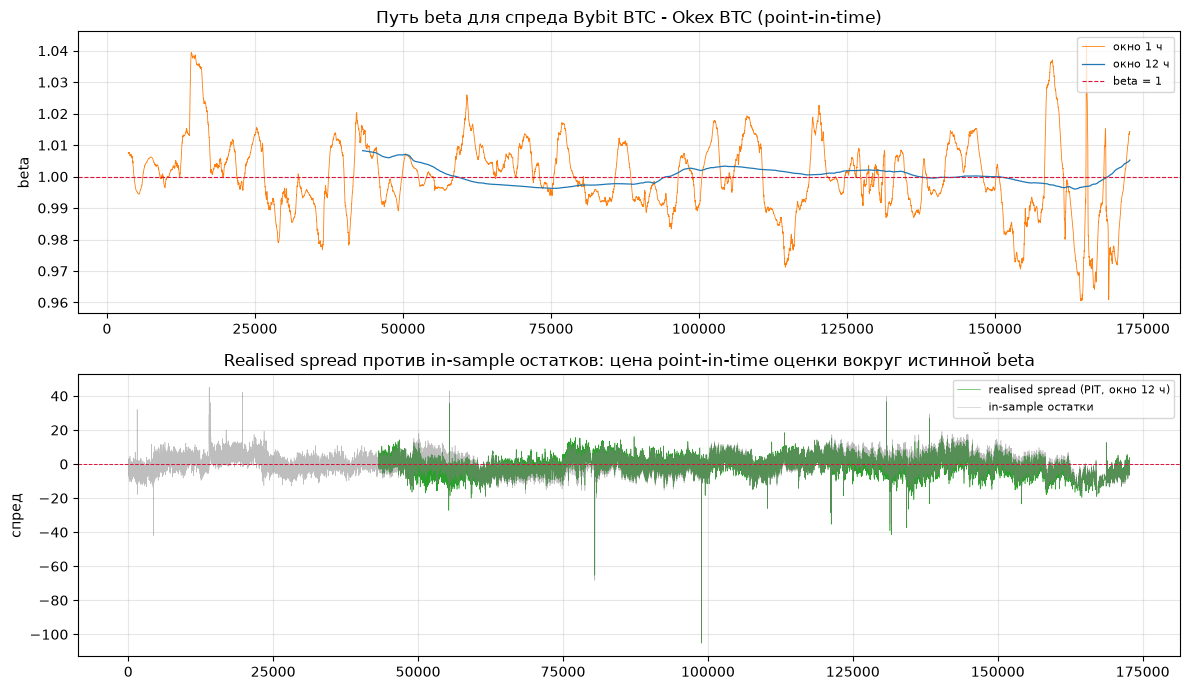

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

ax = axes[0]
ax.plot(beta_paths['1 ч'].index, beta_paths['1 ч'].values, lw=0.6, color='tab:orange', label='окно 1 ч')
ax.plot(beta_paths['12 ч'].index, beta_paths['12 ч'].values, lw=0.9, color='tab:blue', label='окно 12 ч')
ax.axhline(1.0, color='crimson', ls='--', lw=0.8, label='beta = 1')
ax.set_title('Путь beta для спреда Bybit BTC - Okex BTC (point-in-time)')
ax.set_ylabel('beta')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

# realised spread (окно 12 ч) против in-sample остатков
b12, a12 = rolling_beta_alpha(y, x, 43200)
s_real = pd.Series(y - b12 * x - a12, index=pair_ts)
s_ins = pd.Series(fit_full.resid, index=pair_ts)
ax = axes[1]
ax.plot(s_real.index, s_real.values, lw=0.4, color='tab:green', label='realised spread (PIT, окно 12 ч)')
ax.plot(s_ins.index, s_ins.values, lw=0.4, color='tab:grey', alpha=0.5, label='in-sample остатки')
ax.axhline(0.0, color='crimson', ls='--', lw=0.7)
ax.set_title('Realised spread против in-sample остатков: цена point-in-time оценки вокруг истинной beta')
ax.set_ylabel('спред')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

На верхней панели виден характер пути $\beta$: он почти всё время сидит около единицы, но короткое
окно даёт заметные выбросы (до $\pm 4$ %), а длинное их сглаживает. Это и есть ответ про стабильность
связи: направление и масштаб стабильны, но локальная оценка
hedge ratio на коротком окне шумная. На нижней панели видно, что realised spread колеблется вокруг
нуля шире и «рванее», чем in-sample остатки — в этом и выражается плата за отсутствие заглядывания
вперёд.

### 5.1. Сколько half-life укладывается в окно

Отдельная ловушка: если окно слишком короткое по сравнению с half-life процесса, то тест не имеет
мощности — возвращение просто не успевает произойти внутри окна. Это удобно свести в таблицу:
сколько half-life (в секундах, по realised spread) помещается в окно.

In [20]:
rows = []
for r in roll:
    W_sec = {'1 ч': 3600, '4 ч': 14400, '12 ч': 43200}[r['окно']]
    rows.append({'окно': r['окно'], 'окно, с': W_sec,
                 'half-life realised, с': r['half-life realised, с'],
                 'half-life в окне': round(W_sec / r['half-life realised, с'], 1)})
display(pd.DataFrame(rows))

,окно,"окно, с","half-life realised, с",half-life в окне
0,1 ч,3600,2.68,1343.3
1,4 ч,14400,3.94,3654.8
2,12 ч,43200,5.11,8454.0


Даже в часовом окне укладывается больше тысячи half-life — то есть по «разрешению» окна
возвращение видно с огромным запасом. Факт обманчивый: окно
достаточно длинное **относительно процесса**, но о том, сколько независимых
режимов успело смениться, он не говорит ничего. Циклы возвращения частые, а режимы редкие: $\beta$ на часовом масштабе стабильна, а
стационарность спреда всё равно нарушается (пункт 4.1).

### 5.2. Тот же rolling на BTC~ETH: здесь $\beta$ действительно оценивается

На паре одной монеты $\beta$ известна заранее, и вывод про переобучение там — только про сам механизм.
Теперь то же самое на BTC против ETH (Bybit, 1-с сетка): $\beta$ не известна, глобальная оценка из
пункта 4.2 равна $\approx 23.4$, и отношение монет может дрейфовать. Окна те же: 1 ч / 4 ч / 12 ч.

In [21]:
print('=== rolling point-in-time: BTC ~ ETH (Bybit, 1 s) — beta оценивается заново ===')
pair_e = pd.concat([MID['1s']['Bybit_BTC'], MID['1s']['Bybit_ETH']], axis=1).dropna()
ye, xe = pair_e.iloc[:, 0].values, pair_e.iloc[:, 1].values
fit_e = sm.OLS(ye, sm.add_constant(xe)).fit()
TEST_COUNTER['OLS'] += 1
st_e = test_stationarity(fit_e.resid, 'in-sample resid BTC~ETH')
phi_e, hl_e = half_life_ar1(fit_e.resid)
print(f"in-sample: beta={fit_e.params[1]:.2f}, R2={fit_e.rsquared:.4f}; остатки: "
      f"ADF={st_e['ADF']} (p={st_e['ADF p']}), KPSS={st_e['KPSS']} (p={st_e['KPSS p']}), "
      f"phi={phi_e:.4f}, half-life={hl_e:.0f} с")

roll_e = []
beta_paths_e = {}
for W, label in [(3600, '1 ч'), (14400, '4 ч'), (43200, '12 ч')]:
    b, a = rolling_beta_alpha(ye, xe, W)
    s_ = ye - b * xe - a
    ok = ~np.isnan(s_)
    ss = s_[ok]
    st = test_stationarity(ss, f'realised ETH {label}')
    phi, hl = half_life_ar1(ss)
    beta_paths_e[label] = pd.Series(b, index=pair_e.index)
    roll_e.append({'окно': label, 'beta min': round(np.nanmin(b), 1),
                   'beta median': round(np.nanmedian(b), 1), 'beta max': round(np.nanmax(b), 1),
                   'ADF realised': st['ADF'], 'ADF p': st['ADF p'],
                   'KPSS realised': st['KPSS'], 'KPSS p': st['KPSS p'],
                   'half-life realised, с': round(hl, 0)})
display(pd.DataFrame(roll_e))

=== rolling point-in-time: BTC ~ ETH (Bybit, 1 s) — beta оценивается заново ===


in-sample: beta=23.45, R2=0.9125; остатки: ADF=-1.617 (p=0.474), KPSS=15.779 (p=0.01), phi=0.9999, half-life=13579 с


,окно,beta min,beta median,beta max,ADF realised,ADF p,KPSS realised,KPSS p,"half-life realised, с"
0,1 ч,0.4,29.1,62.9,-11.602,0.0000,0.395,0.0793,285.0
1,4 ч,6.8,32.4,51.5,-6.283,0.0000,6.607,0.0100,927.0
2,12 ч,6.8,31.9,36.9,-3.549,0.0068,25.233,0.0100,2671.0


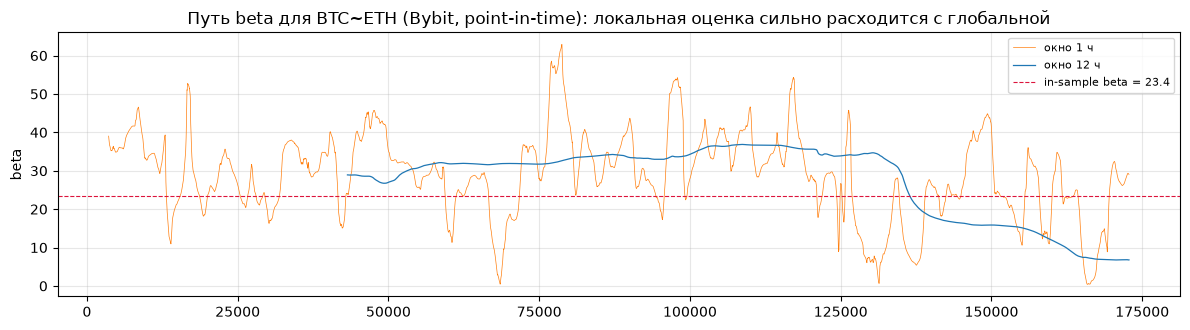

In [22]:
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(beta_paths_e['1 ч'].index, beta_paths_e['1 ч'].values, lw=0.5, color='tab:orange',
        label='окно 1 ч')
ax.plot(beta_paths_e['12 ч'].index, beta_paths_e['12 ч'].values, lw=0.9, color='tab:blue',
        label='окно 12 ч')
ax.axhline(fit_e.params[1], color='crimson', ls='--', lw=0.8,
           label=f'in-sample beta = {fit_e.params[1]:.1f}')
ax.set_title('Путь beta для BTC~ETH (Bybit, point-in-time): локальная оценка сильно расходится с глобальной')
ax.set_ylabel('beta')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Картина переворачивается — и это самый полезный результат пункта 5.

Во-первых, путь $\beta$ нестабилен: часовое окно гоняет оценку от $0.4$ до $63$ при глобальных
$23.4$ — отношение ETH/BTC за 48 ч уходит то в одну, то в другую сторону, и локальная регрессия
идёт за ним (на 12 ч разброс уже $[6.8; 36.9]$, но и там медиана $\approx 32$ против
глобальных $23.4$).

Во-вторых, in-sample остатки одной глобальной регрессии **не** стационарны по ADF ($-1.62$ — та же
статистика, что и Engle–Granger в 4.2) и отвергаются по KPSS ($15.8$ при $p \le 0.01$): вердикт по
нашему правилу — тесты расходятся, единого коинтегрирующего вектора на двух днях нет. Их half-life
по AR(1) — $13\,600$ с ($\approx 3.8$ ч) при $\varphi = 0.9999$: формально возврат есть, но это
граница применимости AR(1)-приближения, цифру надо читать как «очень медленно».

В-третьих, stitched realised spread ведёт себя иначе: на часовом окне ADF $-11.6$ при $p < 0.001$,
а KPSS $0.40$ — на 5 %-ном уровне не отвергает, хотя и впритык (критическое $0.463$). Формально это
единственный ряд среди спредов в этом ноутбуке, где оба теста согласуются на I(0)
(доходности — тоже I(0) по согласию, но спредом нет). Half-life — $285$ с,
минуты, а не секунды, как у cross-venue спреда. С ростом окна ADF слабеет ($-6.3$ на 4 ч, $-3.5$
на 12 ч), а KPSS, наоборот, отвергает сильнее ($6.6$ и $25.2$): длинное окно тащит в спред медленный
дрейф отношения.

Смысл и оговорка. На Bybit–Okex in-sample фит корректен ($\beta = 1$ изначально), и
локальная оценка только добавляет шума — realised спред оказывается хуже in-sample. На BTC–ETH
in-sample фит смещён: одна глобальная $\beta$ не покрывает дрейф отношения — это model
misspecification, а не классический overfit. Локальная оценка этот дрейф вычитает, и по статистикам
realised спред оказывается *лучше* in-sample — но «лучше» здесь означает адаптацию к локальному
дрейфу отношения, а не улучшение модели: торгуемости спреду это не добавляет. Значит, механизм
переобучения hedge ratio — не односторонний штраф: он дорого стоит, когда модель верна, и оборачивается
адаптацией, когда модель неверна. Но торговать этим как находкой нельзя: Engle–Granger коинтеграцию
не подтвердил (ни в одну из сторон), согласованное I(0) получено только на одном окне из трёх,
а испытаний в этом пункте было много. Это режимно-зависимая связь с почасовым переобучением `hedge ratio`,
а не стационарный спред.

## Пункт 6 — report the limits: что два дня показать не могут

Собираем границы по порядку.

**Сколько тестов сделано.** Одно число важно само по себе: множественные сравнения — источник
ложных находок. Счётчик ведётся по ходу ноутбука и ниже печатается таблицей. На реальных рядах 68
испытаний — это тесты с порогом 5 %: 32 ADF и 30 KPSS (уровни и доходности по трём каденсам,
спреды, чувствительность к лагам, rolling-окна двух пар) плюс 6 тестов Engle–Granger (три биржи,
каждая регрессия в обе стороны). Ещё 22 — оценки, а не тесты: 14 AR(1) на half-life и 8 OLS, у
которых нет p-value, и в поправку на множественность они не входят. На 68 тестах с порогом
ожидаемое число ложных срабатываний — около трёх с половиной даже при полном отсутствии связи.
Поэтому ни один отдельный $p$-value здесь не принимается как открытие: выводы мы строим на
**согласии** ADF и KPSS и на устойчивости к смене каденса и окна, а не на одном пороге.

**Что два дня не могут показать.** Это главный лимит по содержанию. Мощность теста на коинтеграцию
зависит не от числа точек, а от **span** — длины наблюдения в единицах half-life процесса (слайд 15).
Отношения дневного масштаба требуют дней и недель наблюдения: при двух днях и даже $n=5000$ точек
мощность обнаружить half-life порядка одного дня — около $6$ %. Поэтому вердикт «BTC–ETH не
коинтегрированы» надо читать буквально: **на двух днях и секундных приращениях коинтеграция
дневного масштаба не обнаруживается** — и это не доказательство её отсутствия. Тест из пункта 4.2 — настоящая
проверка того, умеем ли мы находить коинтеграцию, — её **не проходит**, и это провал, а не
отрицательный научный результат.

**Что не построить на этих данных.** В файлах только L2 перпетуалов — нет funding, нет spot, нет
dated-контрактов. Значит, funding-adjusted spread (идея со слайда 32) **не строится**: чтобы
скорректировать цену перпетуала на стоимость удержания, нужен ряд ставок funding, которого в
выгрузке нет, а заменять его знаком или константой — значит выдумывать данные.

**Что почти не удивляет.** Cross-venue спред одной и той же монеты (BTC на Bybit против
BTC на Okex) почти стационарен **по построению**: это закон одной цены, и любое отклонение — это
почти арбитраж, который закрывается за секунды. Наши $-9.9 \ldots -11.4$ по ADF (с поиском лага по AIC;
при коротких фиксированных лагах — до $-35$, см. 4.1.1) и half-life около 6 с на 1-с сетке
подтверждают это, но не открывают: мы заранее знали, что одна монета на двух биржах связана. Именно
поэтому настоящий тест — это BTC против ETH, и он не прошёл.

**Оговорка про hidden leg.** Все три площадки котируются в USDT, а USDT — не риск-нейтральная нога:
его курс к доллару сам — стохастический процесс. Если считать «цену BTC» относительно USD,
то в наш спред между биржами входит ещё и разница между их stablecoin-ногами, которой мы не видим.
На 48 часах это мало (USDT на всех трёх площадках — фактически один и тот же инструмент), но для длинных окон это скрытая
нога риска, а не техническая мелочь.

**Оговорка про режимность.** Спред ADF-стационарен, а KPSS нет — это не противоречие, а указание на
смену режимов. На двух днях мы видели только один-два крупных эпизода волатильности BTC, поэтому
оценить, как часто режимы меняются и как спред ведёт себя в каждом, невозможно. Это уже не
техническое ограничение, а вопрос дизайна выборки.

In [23]:
print('=== Счётчик статистических испытаний (ведётся по ходу ноутбука) ===')
tc = pd.Series(TEST_COUNTER).rename_axis('тип испытания').to_frame('число')
tc.loc['итого'] = tc['число'].sum()
display(tc)

=== Счётчик статистических испытаний (ведётся по ходу ноутбука) ===


,число
тип испытания,
ADF,32
KPSS,30
AR(1),14
OLS,6008
coint,6
итого,6090


In [24]:
print('Итог по пунктам задания')
print('1. series      : сетки 1 s / 5 s / 30 s, покрытие >= 99.98 % на всех каденсах; ffill')
print('                 не заполнил ни одного значения (все пропуски — стартовая метка)')
print('2. each series : уровни I(1) (ADF не отвергает, KPSS отвергает),')
print('                 доходности I(0) (ADF отвергает, KPSS не отвергает) — на всех трех биржах')
print('3. control     : независимые random walk дают R2 ~ 0.23..0.24 и P(|t|>1.96) 0.76..0.94')
print('                 (2000 реплик, SE ~ 0.01); диагноз Грейнджера-Ньюболда: R2 >> DW')
print('4. pairs       : beta=1 cross-venue ADF отвергает (mean reversion, ~6 с на 1-с сетке;')
print('                 оценка half-life зависит от каденса), но KPSS отвергает стационарность —')
print('                 режимность; Engle-Granger BTC~ETH НЕ находит коинтеграцию')
print('                 (t -1.62 и -1.29, обе стороны)')
print('5. rolling     : 1 ч / 4 ч / 12 ч. На beta=1-паре beta около 1.0, короткое окно шумит и')
print('                 занижает half-life. На BTC~ETH beta ходит от 0.4 до 63, in-sample остатки')
print('                 не стационарны, а PIT-spread часового окна согласованно I(0) (ADF -11.6):')
print('                 связь есть, но режимно-зависимая, не коинтеграция')
print('6. limits      : 2 дня не тестируют отношения дневного масштаба (power ~6 % при half-life 1 день);')
print('                 нет funding/spot, funding-adjusted spread не строится;')
print('                 cross-venue спред стационарен по построению — не открытие;')
print('                 90 испытаний на реальных рядах, из них 68 тестов с порогом (см. счётчик);')
print('                 hidden leg: quote currency USDT как скрытая нога')

Итог по пунктам задания
1. series      : сетки 1 s / 5 s / 30 s, покрытие >= 99.98 % на всех каденсах; ffill
                 не заполнил ни одного значения (все пропуски — стартовая метка)
2. each series : уровни I(1) (ADF не отвергает, KPSS отвергает),
                 доходности I(0) (ADF отвергает, KPSS не отвергает) — на всех трех биржах
3. control     : независимые random walk дают R2 ~ 0.23..0.24 и P(|t|>1.96) 0.76..0.94
                 (2000 реплик, SE ~ 0.01); диагноз Грейнджера-Ньюболда: R2 >> DW
4. pairs       : beta=1 cross-venue ADF отвергает (mean reversion, ~6 с на 1-с сетке;
                 оценка half-life зависит от каденса), но KPSS отвергает стационарность —
                 режимность; Engle-Granger BTC~ETH НЕ находит коинтеграцию
                 (t -1.62 и -1.29, обе стороны)
5. rolling     : 1 ч / 4 ч / 12 ч. На beta=1-паре beta около 1.0, короткое окно шумит и
                 занижает half-life. На BTC~ETH beta ходит от 0.4 до 63, in-sample остатки
         